c:\Users\emill\anaconda3\envs\coupe_env\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\emill\anaconda3\envs\coupe_env\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


Global mean for IR_bigram_esidaine: 16.638322


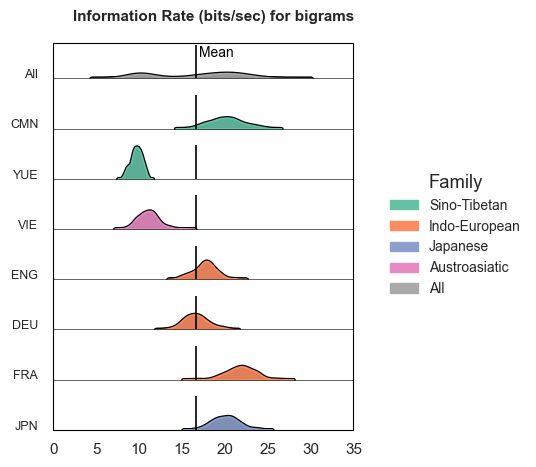

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

def IR_histogram():
    """
    Function to plot histograms of Information Rate (IR) across languages.
    """

    # Choose IR type
    IR_type = "IR_bigram_esidaine" 

    # Load data
    df_IR = pd.read_csv(
        "C:/Users/emill/Documents/GitHub/Coupe_Expansion/emillys_code/syll_comparison_coupe_esidaine.csv",
        encoding="utf-8",
        sep=","
    )

    df_SR = pd.read_csv(
        "C:/Users/emill/Documents/GitHub/Coupe_Expansion/AutomaticSylDetect.csv",
        encoding="utf-8",
        sep="\t"
    )

    # Clean column names
    df_IR.columns = df_IR.columns.str.strip()
    df_SR.columns = df_SR.columns.str.strip()

    # Add SR to IR dataframe
    df_IR["SR"] = df_SR["speechrate"].values

    assert IR_type in df_IR.columns, f"{IR_type} not found in df_IR columns"
    # Subset columns
    df_IR = df_IR[["Language", "Text", "Speaker", IR_type , "SR"]]

    # Filter only the selected languages
    languages = ["FRA", "JPN", "CMN", "VIE", "YUE", "ENG", "DEU"]
    df_IR = df_IR[df_IR["Language"].isin(languages)]

    # Map language families
    df_IR["Family"] = df_IR["Language"].map({
        "FRA": "Indo-European",
        "JPN": "Japanese",
        "CMN": "Sino-Tibetan",
        "VIE": "Austroasiatic",
        "YUE": "Sino-Tibetan",
        "ENG": "Indo-European",
        "DEU": "Indo-European"
    })

    # Melt for plotting
    df_long = pd.melt(df_IR, 
                    id_vars=["Language", "Text", "Speaker", "Family"],
                    value_vars=["SR", IR_type],
                    var_name="variable", 
                    value_name="value")

    # add alpha column (e.g., for plotting transparency)
    df_long["alpha"] = 0.1

    xlim_dict = {
        "IR_unigram_esidaine": (15, 75),
        "IR_bigram_esidaine": (0, 35),
        "IR_trigram_esidaine": (0, 15),
        "IR_4gram_esidaine": (0, 8)
    }
    xlim = xlim_dict.get(IR_type, (10, 65))  

    ngram_label = IR_type.split("_")[1] + "s"

    # Prepare the data
    df_sn = df_IR[df_IR['Language'] != 'All']
    df_sn = df_sn.melt(id_vars=['Language', 'Family'], 
                    value_vars=[IR_type, 'SR'], 
                    var_name='Metric', value_name='Value')
    df_sn = df_sn[df_sn['Metric'] == IR_type].dropna()

    # Add aggregated "All" row
    all_data = df_sn.copy()
    all_data["Language"] = "All"
    all_data["Family"] = "All"
    df_sn = pd.concat([df_sn, all_data], axis=0)


    ordered_languages = ["All", "CMN", "YUE", "VIE", "ENG", "DEU", "FRA", "JPN"]
    df_sn['Language'] = pd.Categorical(df_sn['Language'],
                                    categories=ordered_languages,
                                    ordered=True)

    # Setup seaborn
    sns.set(style="white", font_scale=1.1)

    # Create color palette by Family
    unique_families = df_sn['Family'].dropna().unique()

    custom_palette = sns.color_palette("Set2", n_colors=len(unique_families))
    palette_dict = {fam: color for fam, color in zip(unique_families, custom_palette)}
    palette_dict["All"] = "#A9A9A9"   # Dark grey color for "All"
    df_sn["Color"] = df_sn["Family"].map(palette_dict)

    # Plot
    g = sns.FacetGrid(df_sn, row="Language", hue="Family", aspect=5, height=0.8, 
                    palette=palette_dict, margin_titles=True)

    # KDE per language
    def kde_with_outline(data, color, **kwargs):
        # Draw thick black outline first
        sns.kdeplot(data=data, x="Value", fill=True, color="black", alpha=1.0,
                    linewidth=3.0, **kwargs)
        # Then overlay the colored KDE
        sns.kdeplot(data=data, x="Value", fill=True, color=color, alpha=0.9,
                    linewidth=1.2, **kwargs)

    g.map_dataframe(kde_with_outline)

    # Draw KDE boundaries and mean
    def draw_one_vertical_line_in_each_axis(global_mean):
        for i, ax in enumerate(g.axes.flat):
            # Only draw in the leftmost axis (row "All")
            if i == 0:
                ax.axvline(global_mean, color='black', linestyle='-', linewidth=1.2)
                ax.text(global_mean + 0.3, 0.55, "Mean",
                        transform=ax.get_xaxis_transform(),
                        fontsize=10, color='black', weight='light',
                        ha='left', va='bottom')
            else:
                ax.axvline(global_mean, color='black', linestyle='-', linewidth=1.2)
    # Set dynamic xlim for all axes
    for ax in g.axes.flat:
        ax.set_xlim(*xlim)

    global_mean = df_IR[df_IR['Language'] != 'All'][IR_type].mean()
    print(f"Global mean for {IR_type}: {global_mean:.6f}")
    draw_one_vertical_line_in_each_axis(global_mean)

    g.set_titles(row_template="{row_name}", col_template="", size=10)

    # Remove vertical facet labels (the default row labels)
    for ax in g.axes[:, 0]:  # Only need to do this for one column
        if hasattr(ax, 'get_ylabel'):
            ax.set_ylabel("")

    for ax, label in zip(g.axes.flat, df_sn['Language'].cat.categories):
        ax.text(-0.05, 0.1, label, transform=ax.transAxes,
                fontsize= 9 , va='center', ha='right', rotation=0)

        
    # Remove default right-side facet titles
    g.set_titles(row_template="")  # Removes default titles

    # Hide all y-ticks and labels
    for ax in g.axes.flat:
        ax.set_ylabel("")
        ax.set_yticks([])

    for ax in g.axes.flat:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)


    xtick_vals = list(range(xlim[0], xlim[1] + 1, 5))
    g.set(yticks=[], ylabel="")
    g.set(xticks=xtick_vals, xlabel="")
    g.set_xticklabels([str(x) for x in xtick_vals], fontsize=11)
    g.despine(left=True, bottom=False)
    plt.subplots_adjust(hspace=0.5, left=0.1, right=0.85)
    plt.suptitle(f"Information Rate (bits/sec) for {ngram_label}", fontsize=11, fontweight='bold', y=0.95)

    # Create a square-based legend with border
    legend_handles = [
        mpatches.Patch(color=palette_dict[f], label=f) for f in palette_dict
    ]
    legend = g.fig.legend(
        handles=legend_handles,
        title="Family",
        loc='center right',
        bbox_to_anchor=(1.3, 0.5),
        frameon=False, 
        edgecolor='black', 
        fontsize = '10'
    )
    g.fig.set_size_inches(4, 5) 

    # Add rectangle around the figure area
    g.figure.patches.append(Rectangle(
        (0.1, 0.11), 0.75, 0.774,  # (x,y), width, height in figure coordinates
        linewidth=0.8, edgecolor='black', facecolor='none',
        transform=g.figure.transFigure, clip_on=False
    ))
    plt.savefig(f"C:/Users/emill/Documents/GitHub/Coupe_Expansion/emillys_code/images/IR_across_Languages_{ngram_label}.png", dpi=300, bbox_inches='tight')
    plt.show()

IR_histogram()

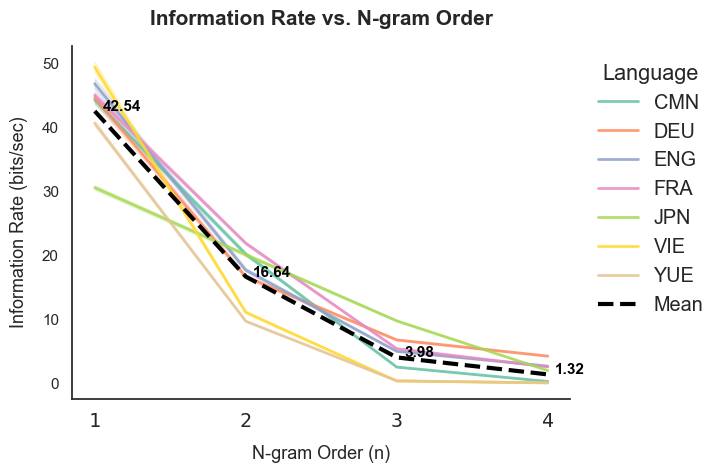

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_inforate_vs_ngram_order():
    """
    Plot Information Rate vs. N-gram Order for different languages (line plot).
    """

    # Load and filter
    df_IR = pd.read_csv(
        "C:/Users/emill/Documents/GitHub/Coupe_Expansion/emillys_code/syll_comparison_coupe_esidaine.csv",
        encoding="utf-8",
        sep=","
    )
    df_IR.columns = df_IR.columns.str.strip()
    languages = ["FRA", "JPN", "CMN", "VIE", "YUE", "ENG", "DEU"]
    df_IR = df_IR[df_IR["Language"].isin(languages)]

    # Prepare data
    ir_cols = [col for col in df_IR.columns if col.startswith("IR_") and "esidaine" in col]
    df_ir = df_IR[["Language"] + ir_cols].copy()
    df_IR_long = df_ir.melt(id_vars="Language", var_name="Metric", value_name="IR")
    df_IR_long["n"] = df_IR_long["Metric"].str.extract(r"IR_(unigram|bigram|trigram|4gram)")
    ngram_order = {"unigram": 1, "bigram": 2, "trigram": 3, "4gram": 4}
    df_IR_long["n"] = df_IR_long["n"].map(ngram_order)

    # Set style
    sns.set_context("notebook", font_scale=1.3)
    sns.set_style("white")
    plt.figure(figsize=(7.5, 5))

    # Custom color palette
    custom_palette = sns.color_palette("Set2", n_colors=len(languages))
    sns.lineplot(data=df_IR_long, x="n", y="IR", hue="Language",
                palette=custom_palette, linewidth=2, alpha=0.85)

    # Add mean line
    df_mean = df_IR_long.groupby("n", as_index=False)["IR"].mean()
    sns.lineplot(data=df_mean, x="n", y="IR", color="black", label="Mean",
                linewidth=3, linestyle='--')

    # Annotate mean
    for i, row in df_mean.iterrows():
        plt.text(row["n"] + 0.05, row["IR"] + 0.04, f"{row['IR']:.2f}",
                color='black', fontsize=11, fontweight='bold')

    # Final plot tweaks
    plt.title("Information Rate vs. N-gram Order", fontsize=15, weight='bold', pad=15)
    plt.xlabel("N-gram Order (n)", fontsize=13, labelpad=10)
    plt.ylabel("Information Rate (bits/sec)", fontsize=13, labelpad=10)
    plt.xticks([1, 2, 3, 4], labels=["1", "2", "3", "4"], family="monospace")
    plt.yticks(fontsize=11)
    plt.legend(title="Language", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    sns.despine()
    plt.grid(False)
    plt.tight_layout()
    plt.savefig("C:/Users/emill/Documents/GitHub/Coupe_Expansion/emillys_code/images/IR_vs_ngram_order.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_inforate_vs_ngram_order()